In [90]:
# Install packages
!pip install -q pandas seaborn matplotlib google-cloud-bigquery



In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import bigquery
from google.oauth2 import service_account
from datetime import datetime

In [92]:
df = pd.read_csv('dl_trends.csv')

In [94]:
df['month'] = pd.to_datetime(df['month'])

pivot_df = df.pivot(index='project', columns='month', values='downloads')

second_last_month = sorted(pivot_df.columns)[-2]

pivot_df_sorted = pivot_df.sort_values(by=second_last_month, ascending=False)

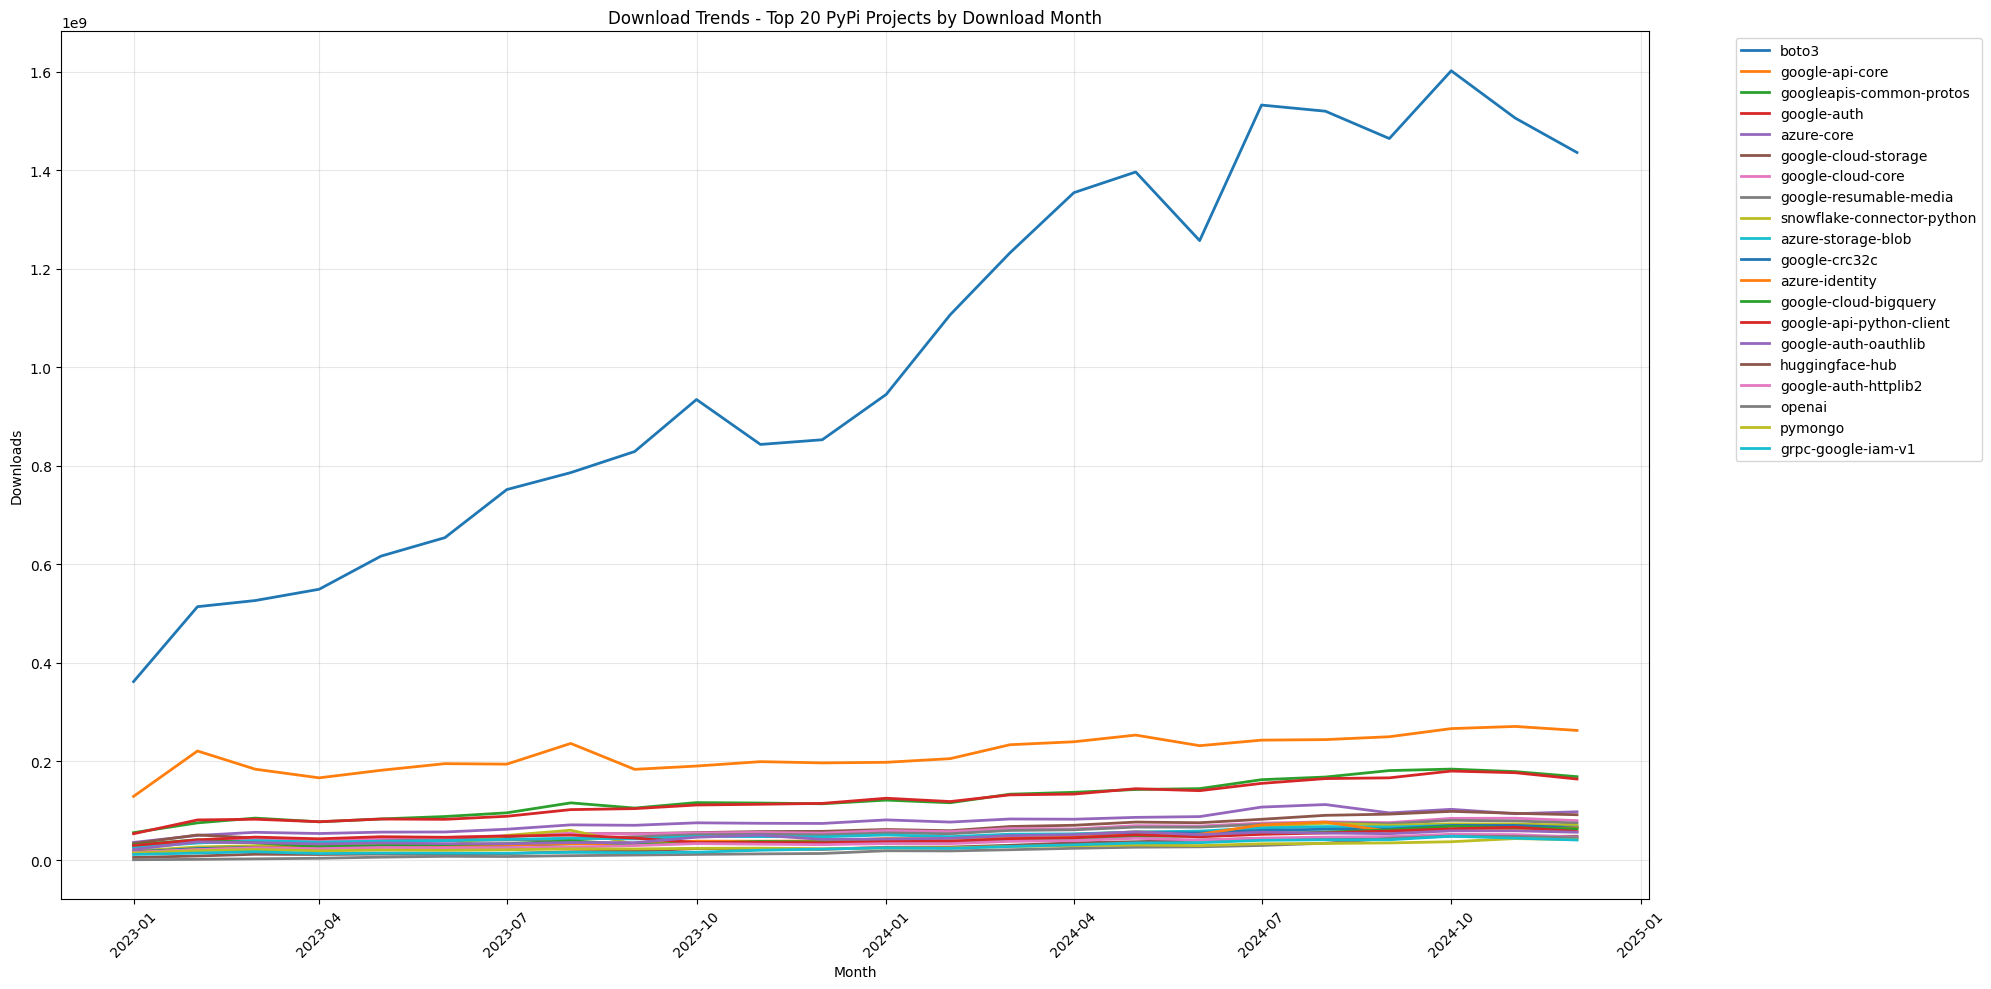

In [95]:
plt.figure(figsize=(20, 10))
top_20_df = pivot_df_sorted.head(20).iloc[:, :-1]
for idx, row in top_20_df.iterrows():
    plt.plot(row.index, row.values, label=idx, linewidth=2)
plt.title('Download Trends - Top 20 PyPi Projects by Download Month')
plt.xlabel('Month')
plt.ylabel('Downloads')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('top_projects_trends.png', bbox_inches='tight', dpi=300)
plt.show()

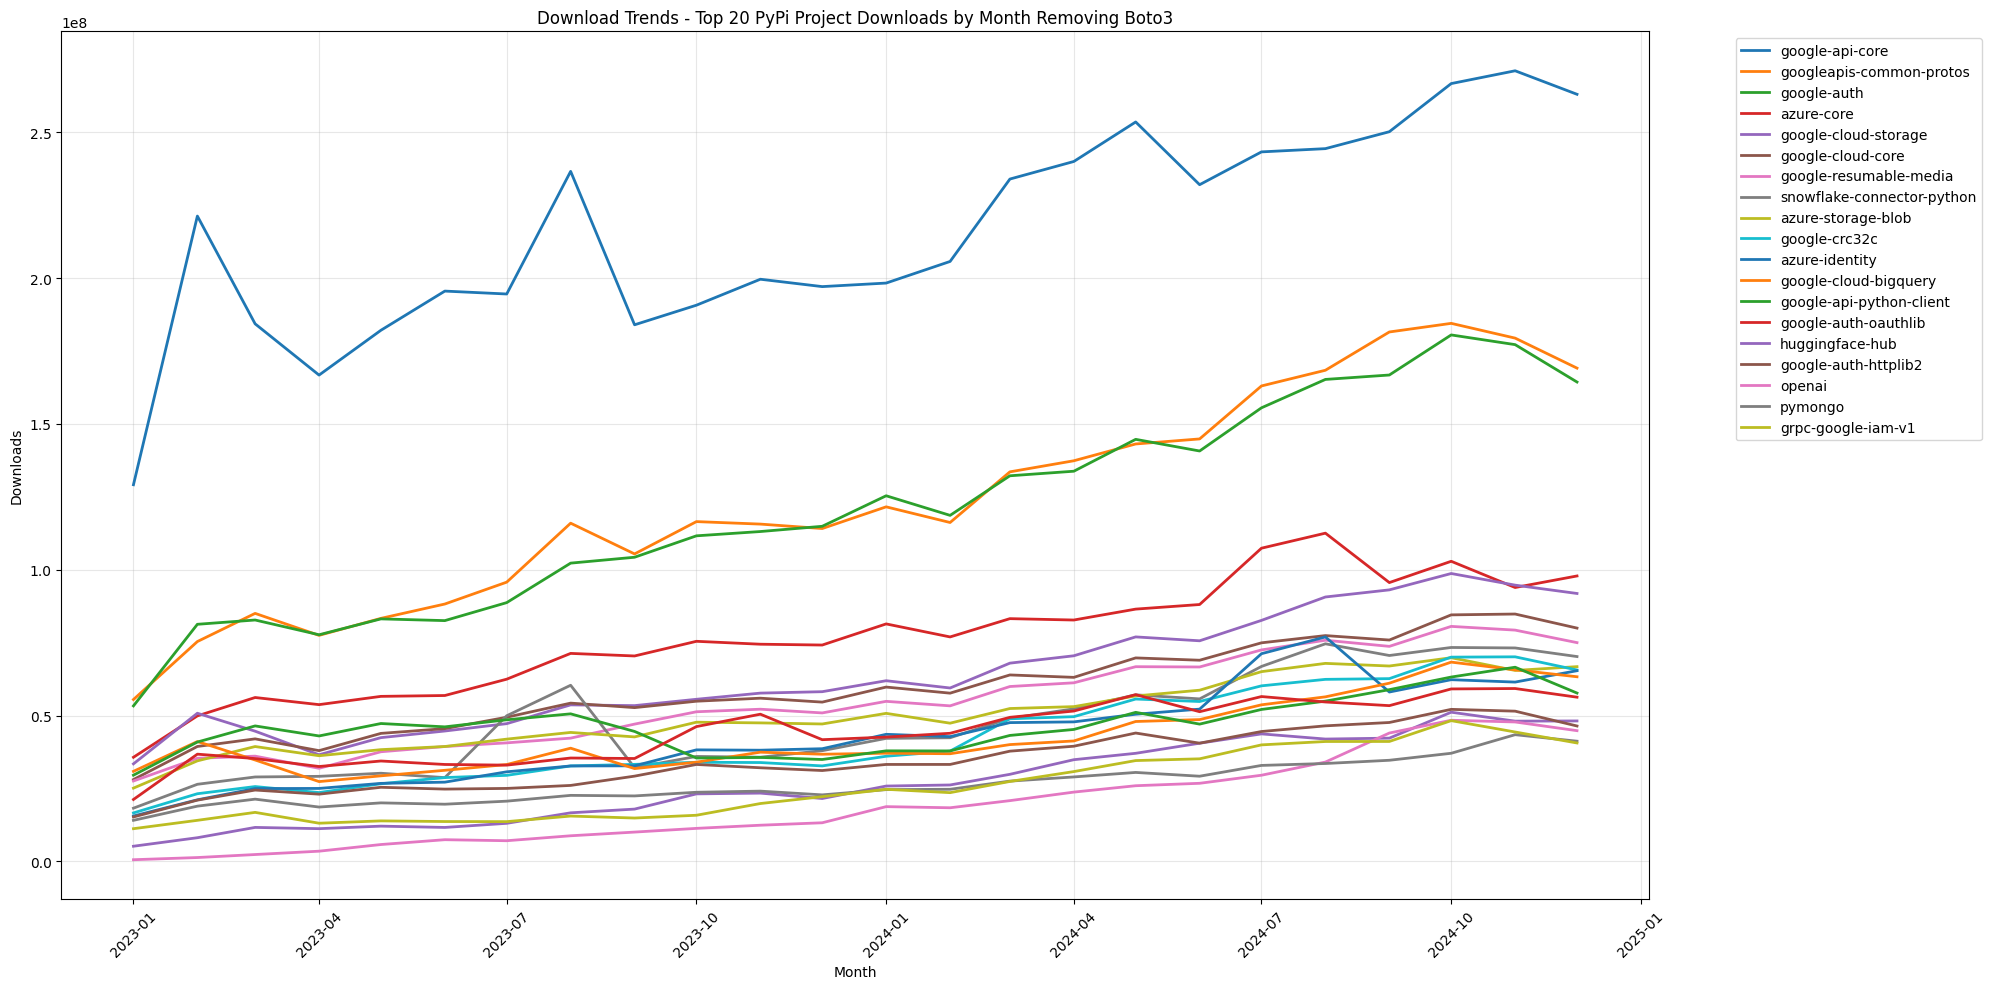

In [96]:
plt.figure(figsize=(20, 10))
top_20_df_sans_boto3 = pivot_df_sorted.head(20).iloc[1:20, :-1]
for idx, row in top_20_df_sans_boto3.iterrows():
    plt.plot(row.index, row.values, label=idx, linewidth=2)
plt.title('Download Trends - Top 20 PyPi Project Downloads by Month Removing Boto3')
plt.xlabel('Month')
plt.ylabel('Downloads')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('top_projects_trends.png', bbox_inches='tight', dpi=300)
plt.show()

In [97]:
pos = ['boto3', 'azure-core', 'google-cloud-core', 'snowflake-connector-python', 'openai']
filtered_df = pivot_df_sorted[pivot_df_sorted.index.isin(pos)].iloc[1:20, :-1]

melted_df = filtered_df.reset_index().melt(
    id_vars=['project'],
    var_name='date',
    value_name='downloads'
)
melted_df.columns = ['project', 'date', 'downloads']

melted_df['date'] = pd.to_datetime(melted_df['date'])
melted_df['year'] = melted_df['date'].dt.year
melted_df['quarter'] = melted_df['date'].dt.quarter

quarterly_df = melted_df.groupby(['project', 'year', 'quarter'])['downloads'].sum().reset_index()

def calculate_yoy_growth(df):
    # Sort by year within each quarter
    df = df.sort_values(['quarter', 'year'])

    # Calculate YoY growth for each quarter
    df['yoy_growth'] = (df['downloads'] / df.groupby('quarter')['downloads'].shift(1) - 1) * 100

    return df

# Calculate growth by project
quarterly_growth = quarterly_df.groupby('project').apply(calculate_yoy_growth).reset_index(drop=True)

# Filter for most recent year's growth (2024 compared to 2023)
latest_growth = quarterly_growth[quarterly_growth['year'] == 2024]


<ipython-input-97-7db51d058f7d>:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  quarterly_growth = quarterly_df.groupby('project').apply(calculate_yoy_growth).reset_index(drop=True)


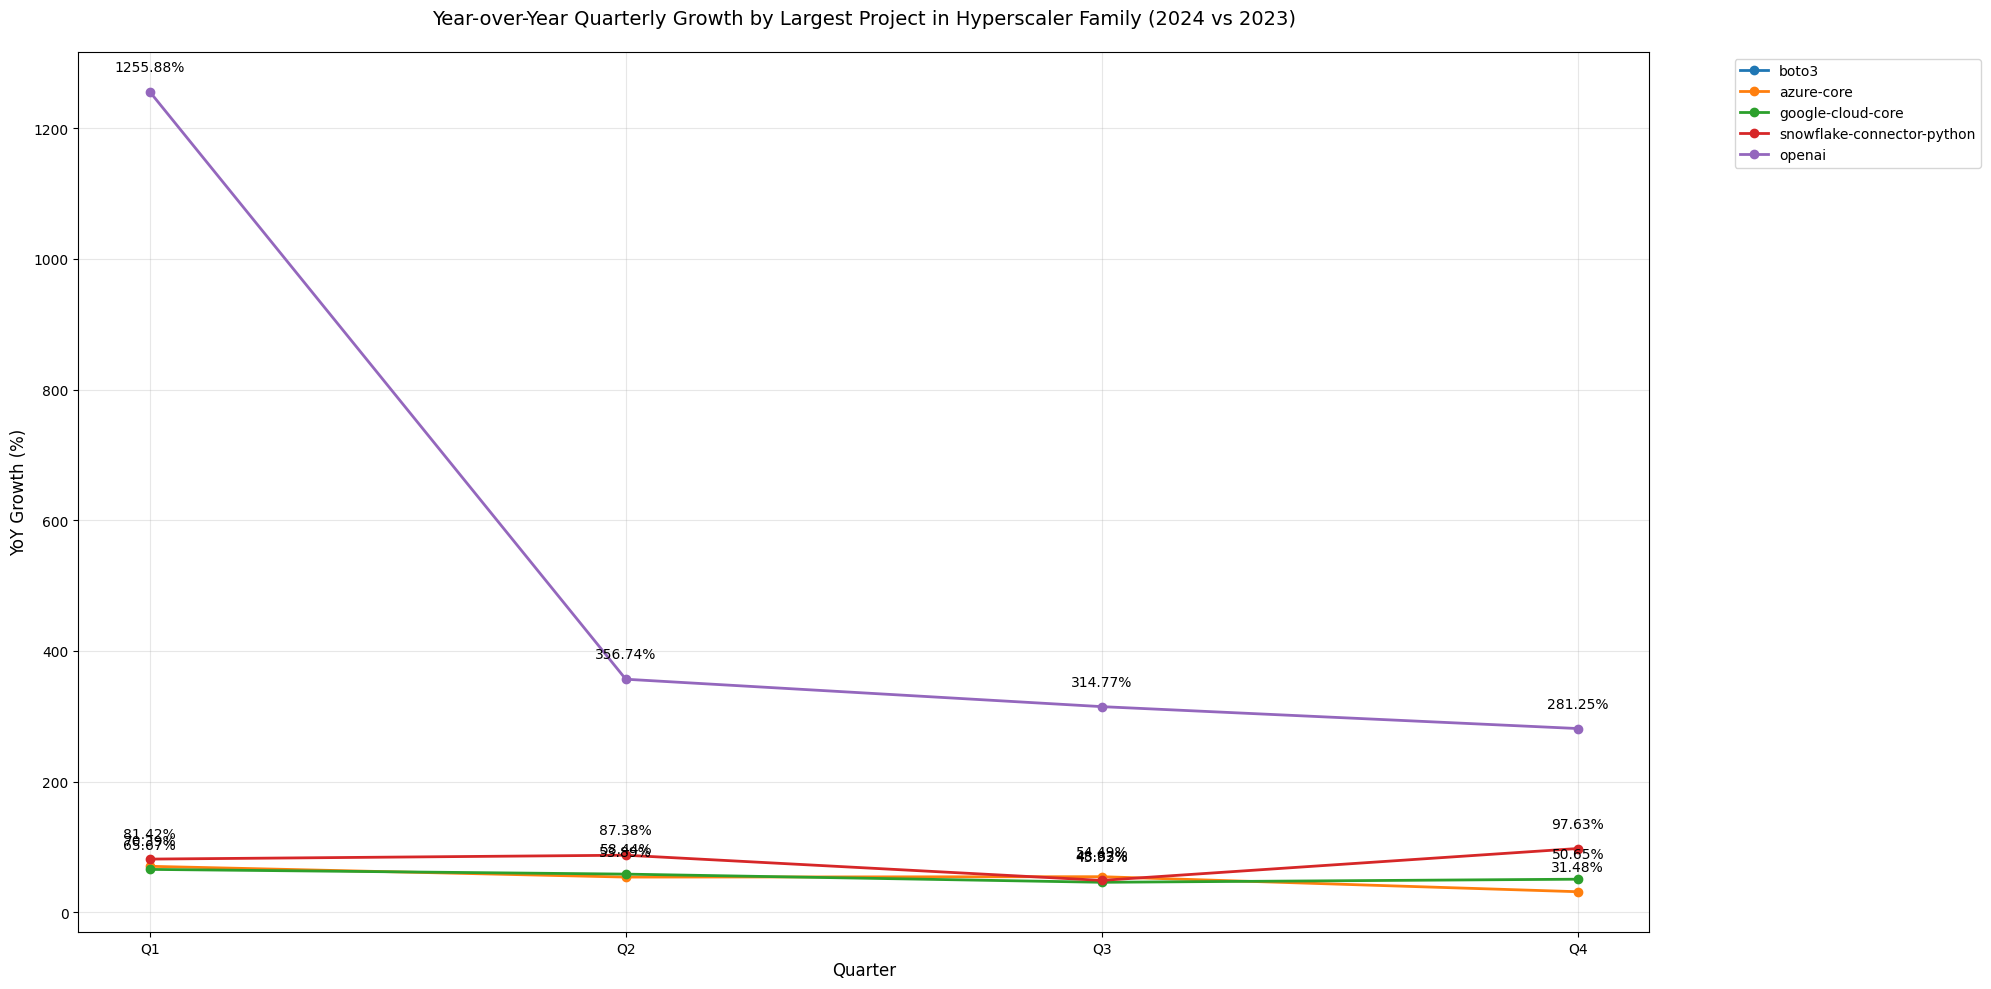

In [98]:
# Plot
plt.figure(figsize=(20, 10))
for project in pos:
    project_data = latest_growth[latest_growth['project'] == project]

    # Sort by quarter to ensure proper line connection
    project_data = project_data.sort_values('quarter')

    plt.plot(project_data['quarter'],
             project_data['yoy_growth'],
             marker='o',
             label=project,
             linewidth=2)

plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])

plt.title('Year-over-Year Quarterly Growth by Largest Project in Hyperscaler Family (2024 vs 2023)', fontsize=14, pad=20)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('YoY Growth (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for project in pos:
    project_data = latest_growth[latest_growth['project'] == project].sort_values('quarter')
    for quarter, growth in zip(project_data['quarter'], project_data['yoy_growth']):
        plt.annotate(f'{growth:.2f}%',
                    (quarter, growth),
                    textcoords="offset points",
                    xytext=(0,15),
                    ha='center')

plt.tight_layout()
plt.show()